# 3D Gaussian Splatting — Volumetric Reconstruction Demo

This notebook tests the `gs3d` library by fitting millions of 3D Gaussians to
a tomographic volume loaded via `ProjectionSliceDataset`.

**Pipeline:**
1. Load tomographic projections → stack into a 3D volume
2. Initialise a `GaussianModel3D` with random Gaussians
3. Optimise with AdamW + adaptive density control (prune / clone / split)
4. Evaluate reconstruction quality (MSE, PSNR, SSIM) and compression ratio
5. Compare against the NAF baseline

## 1. Setup and Imports

In [13]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

# gs3d library
from gs3d import (
    GaussianModel3D,
    VolumeRenderer,
    GaussianOptimizer,
    OptimConfig,
    psnr,
    mse,
    ssim_3d,
    compression_ratio,
)
from gs3d.model import GaussianModelConfig

# Data loading (same as NAF demo)
from inct.dataset_slices import ProjectionSliceDataset
from sdate.datasets.projection_triplet_dataset import (
    TomographyFolderProcessor,
    load_tomography_params,
)

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
    # print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
print("\n✅ All imports successful!")

Using device: cuda
PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe

✅ All imports successful!


## 2. Load Tomographic Data

In [34]:
# ── Configuration ──────────────────────────────────────────────────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 50
TARGET_SIZE = 512      # Smaller size for faster GS testing

if DATA_PATH.exists():
    tomo_params = load_tomography_params(DATA_PATH)
    print(f"✅ Data path exists: {DATA_PATH}")
    for k, v in tomo_params.items():
        print(f"   {k}: {v}")
else:
    print(f"❌ Data path not found: {DATA_PATH}")
    print("   Please update DATA_PATH.")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
✅ Data path exists: /myhome/data/sdate/shared/compression_paper/file_1_extracted
   num_darks: 10
   num_flats: 100
   num_projections: 1501


In [35]:
# Load projections into a 3D volume via ProjectionSliceDataset
if DATA_PATH.exists():
    dataset = ProjectionSliceDataset(
        folder_path=DATA_PATH,
        num_projections=NUM_PROJECTIONS,
        # target_size=TARGET_SIZE,
        normalize_values=True,
        verbose=True,
        cache_volume=True,
        use_attenuation=True,
    )

    # volume shape: (H, W, N_projections)
    volume_raw = dataset.get_full_volume()
    print(f"\n📊 Raw volume shape: {volume_raw.shape}")
    print(f"   Value range: [{volume_raw.min():.4f}, {volume_raw.max():.4f}]")

    # Rearrange to (D, H, W) = (N_proj, H_pix, W_pix)
    # Each 'projection' becomes a depth-slice of the volume to represent
    target_volume = volume_raw.permute(2, 0, 1).contiguous()  # (N, H, W)
    print(f"   Target volume (D, H, W): {target_volume.shape}")
    print(f"   dtype: {target_volume.dtype}")
    print(f"   Total voxels: {target_volume.numel():,}")
    print(f"   Original size (float32): {target_volume.numel() * 4 / 1e6:.1f} MB")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [-0.1997, 1.7837]
ProjectionSliceDataset:
  Volume shape: (2160, 2560, 50)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 5,529,600
Loading 50 projections...
  Loaded 50/50
Volume shape: (2160, 2560, 50)
Total voxels: 276,480,000
Value range: [-0.1077, 1.5697]

📊 Raw volume shape: torch.Size([2160, 2560, 50])
   Value range: [-0.1077, 1.5697]
   Target volume (D, H, W): torch.Size([50, 2160, 2560])
   dtype: torch.float32
   Total voxels: 276,480,000
   Original size (float32): 1105.9 MB


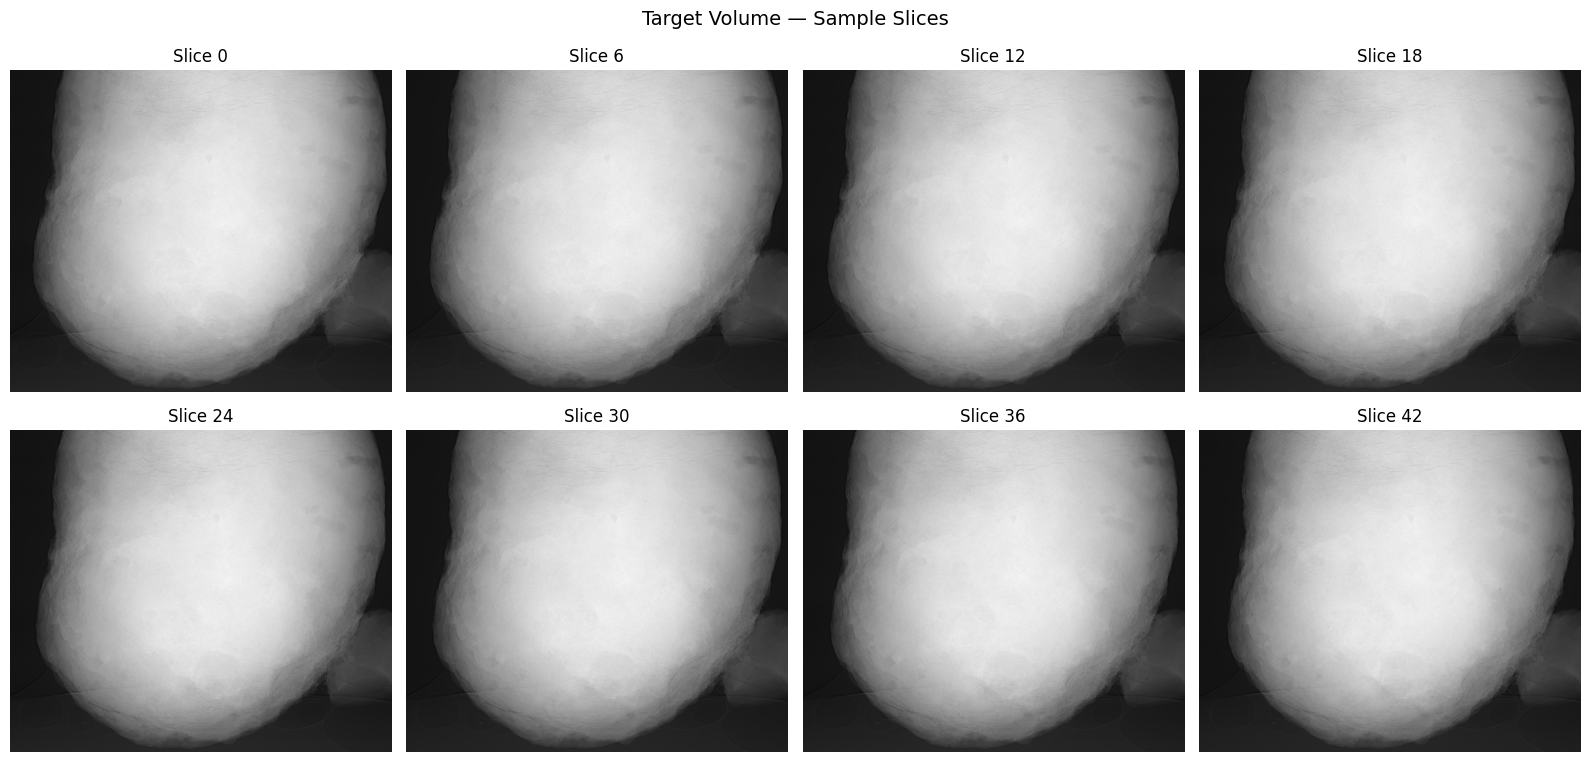

In [36]:
# Visualise a few slices of the target volume
if DATA_PATH.exists():
    D, H, W = target_volume.shape
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    vmin, vmax = float(target_volume.min()), float(target_volume.max())
    for i, ax in enumerate(axes.flat):
        idx = i * (D // 8)
        idx = min(idx, D - 1)
        ax.imshow(target_volume[idx].numpy(), vmin=vmin, vmax=vmax, cmap='gray')
        ax.set_title(f'Slice {idx}')
        ax.axis('off')

    plt.suptitle('Target Volume — Sample Slices', fontsize=14)
    plt.tight_layout()
    plt.show()

## 3. Initialise Gaussian Model

In [38]:
# ── Model configuration ────────────────────────────────────────────────
D, H, W = target_volume.shape

# Start with a moderate number of Gaussians.  Densification will grow
# toward max_gaussians during training — this is the standard 3DGS recipe.
# Starting with 2M all at once would mean ~126K local Gaussians per window,
# making each step extremely expensive.  50K → ~3K local → fast steps.
model_config = GaussianModelConfig(
    n_init=20_000,                  # Start small, densify to 2M
    init_scale_log=-3.5,           # scale ≈ 0.03
    init_intensity_logit=0.5,      # Moderate initial intensity
    volume_extent=(1.0, 1.0, 1.0), # Normalised [0,1]^3 domain
)

model = GaussianModel3D(config=model_config)
print(model.get_info())
print(f"\nModel parameter breakdown:")
for name, p in model.named_parameters():
    print(f"  {name:25s}  {str(tuple(p.shape)):20s}  {p.numel():>10,} params")
print(f"  {'TOTAL':25s}  {'':20s}  {sum(p.numel() for p in model.parameters()):>10,} params")

GaussianModel3D  |  20,000 Gaussians  |  0.88 MB  |  params: means(20000,3) quats(20000,4) log_scales(20000,3) intensity(20000)

Model parameter breakdown:
  _means                     (20000, 3)                60,000 params
  _quats                     (20000, 4)                80,000 params
  _log_scales                (20000, 3)                60,000 params
  _intensity_logit           (20000,)                  20,000 params
  TOTAL                                               220,000 params


## 4. Train — Gaussian Splatting Optimisation (Windowed SGD + Spatial Grid)

The training loop uses **windowed stochastic gradient descent** with a **spatial grid index** for fast Gaussian culling:

1. **Sample a random 3D window** — a contiguous sub-block Ω of the volume
2. **Spatial cull (two-stage)** — only Gaussians whose **rotated bounding box** μ ± c·σ_world overlaps Ω are kept:
   - *Stage 1 (cell-level)*: a uniform 16³ grid identifies which cells overlap the expanded window → O(G³)
   - *Stage 2 (exact)*: rotation-aware axis-aligned bbox check on candidates → O(candidates)
3. **Evaluate locally** — compute the mixture for local Gaussians on window voxels → O(|Ω| × N_local)
4. **Gradient step** — MSE loss → backprop → AdamW update (only touched Gaussians get non-zero gradients)
5. **Adaptive density control** — prune weak Gaussians, clone/split where gradients are large

**Key details:**
- Support cutoff: **3σ** by default (configurable). Beyond 3σ, contribution < exp(−4.5) ≈ 1%.
- Bounding boxes are **rotation-aware**: h_j = c · √Σ_{jj} where Σ = R diag(s²) Rᵀ. The naive per-axis-scale approach would underestimate rotated anisotropic Gaussians by up to 50×.
- The spatial grid is rebuilt every 50 steps to track drifting means, and always after prune/densify.

In [39]:
# Reload gs3d modules to pick up code changes
import importlib
import gs3d.model, gs3d.renderer, gs3d.optimizer, gs3d.metrics, gs3d.spatial, gs3d
importlib.reload(gs3d.model)
importlib.reload(gs3d.renderer)
importlib.reload(gs3d.spatial)
importlib.reload(gs3d.metrics)
importlib.reload(gs3d.optimizer)
importlib.reload(gs3d)

from gs3d import GaussianModel3D, VolumeRenderer, GaussianOptimizer, OptimConfig, psnr, mse, ssim_3d, compression_ratio
from gs3d.model import GaussianModelConfig
print("✅ gs3d modules reloaded (incl. spatial grid)")

✅ gs3d modules reloaded (incl. spatial grid)


In [ ]:
# Normalise the target volume to [0, 1] for the Gaussian model
vol_min = float(target_volume.min())
vol_max = float(target_volume.max())
vol_range = vol_max - vol_min

target_norm = (target_volume - vol_min) / vol_range
print(f"Normalised target range: [{target_norm.min():.4f}, {target_norm.max():.4f}]")

# ── Optim config ────────────────────────────────────────────────────────
optim_config = OptimConfig(
    # Optimiser
    lr_means=2e-4,
    lr_quats=1e-3,
    lr_scales=5e-3,
    lr_intensity=5e-2,

    # Training — 5000 steps; each step ≈ 5-20ms once N_local is small
    num_epochs=5000,
    log_interval=200,
    eval_interval=1000,          # evaluate less often

    # Windowed SGD
    window_size=(20, 256, 256),  # spatial region for Gaussian culling
    voxels_per_step=256*256*20,      # sub-sample voxels from window (16K)
    cutoff_sigma=2.0,            # 3σ support cutoff
    eval_samples=100_000,        # samples for PSNR estimation

    # Spatial grid (kicks in when N > grid_threshold)
    grid_resolution=(16, 16, 16),
    spatial_rebuild_interval=100,
    grid_threshold=50_000,

    # Densification — grow from 50K toward 8M
    densify_from_epoch=100,      # start early
    densify_until_epoch=4000,    # keep growing longer
    densify_interval=50,         # densify more frequently
    grad_threshold=0.0002,
    max_gaussians=8_000_000,
    split_scale_threshold=0.01,

    # Pruning — starts alongside densification
    prune_from_epoch=100,
    prune_interval=100,
    prune_intensity_threshold=0.005,

    # LR schedule
    lr_decay_factor=0.05,

    # Opacity reset
    opacity_reset_interval=500,
)

# Create optimiser (builds spatial grid automatically)
gs_optimizer = GaussianOptimizer(
    model=model,
    target_volume=target_norm,
    config=optim_config,
    device=device,
)

print(f"\n✅ Optimiser ready")
print(f"   Target shape: {target_norm.shape}")
print(f"   Gaussians:   {model.n_gaussians:,}  (will grow to {optim_config.max_gaussians:,} via densification)")
print(f"   Epochs: {optim_config.num_epochs}")
print(f"   Window: {optim_config.window_size}, voxels/step: {optim_config.voxels_per_step:,}")
print(f"   Cutoff: {optim_config.cutoff_sigma}σ")
print(f"   Dynamic B: when N_local is large, voxels are reduced to keep memory ≤ 512 MB")

Normalised target range: [0.0000, 1.0000]

✅ Optimiser ready
   Target shape: torch.Size([50, 2160, 2560])
   Gaussians:   20,000  (will grow to 1,000,000 via densification)
   Epochs: 1000
   Window: (20, 256, 256), voxels/step: 1,310,720
   Cutoff: 2.0σ
   Dynamic B: when N_local is large, voxels are reduced to keep memory ≤ 512 MB


In [41]:
# ── Run training ───────────────────────────────────────────────────────
print("🚀 Starting Gaussian Splatting optimisation...")
print("=" * 60)

history = gs_optimizer.train(verbose=True)

print(f"\n✅ Training complete in {history['training_time']:.1f}s")
print(f"   Final loss: {history['final_loss']:.6f}")
fm = history['final_metrics']
print(f"   Final PSNR: {fm['psnr']:.2f} dB")
print(f"   Final MSE:  {fm['mse']:.6f}")
print(f"   Gaussians:  {fm['n_gaussians']:,}")
print(f"   Model size: {fm['model_mb']:.2f} MB")

🚀 Starting Gaussian Splatting optimisation...
[Epoch     0/1000]  loss=14.948096  N=20,000
         PSNR=-14.82 dB  MSE=30.326351  model=0.88 MB
[Epoch   200/1000]  loss=23.346420  N=223,262  added=113182
[Epoch   400/1000]  loss=97.531609  N=1,000,000
[Epoch   600/1000]  loss=0.302360  N=1,000,000
[Epoch   800/1000]  loss=0.460896  N=1,000,000
[Epoch   999/1000]  loss=0.371030  N=1,000,000

✅ Training complete in 172.7s
   Final loss: 0.371030
   Final PSNR: 8.41 dB
   Final MSE:  0.144082
   Gaussians:  1,000,000
   Model size: 44.00 MB


## 5. Training Curves

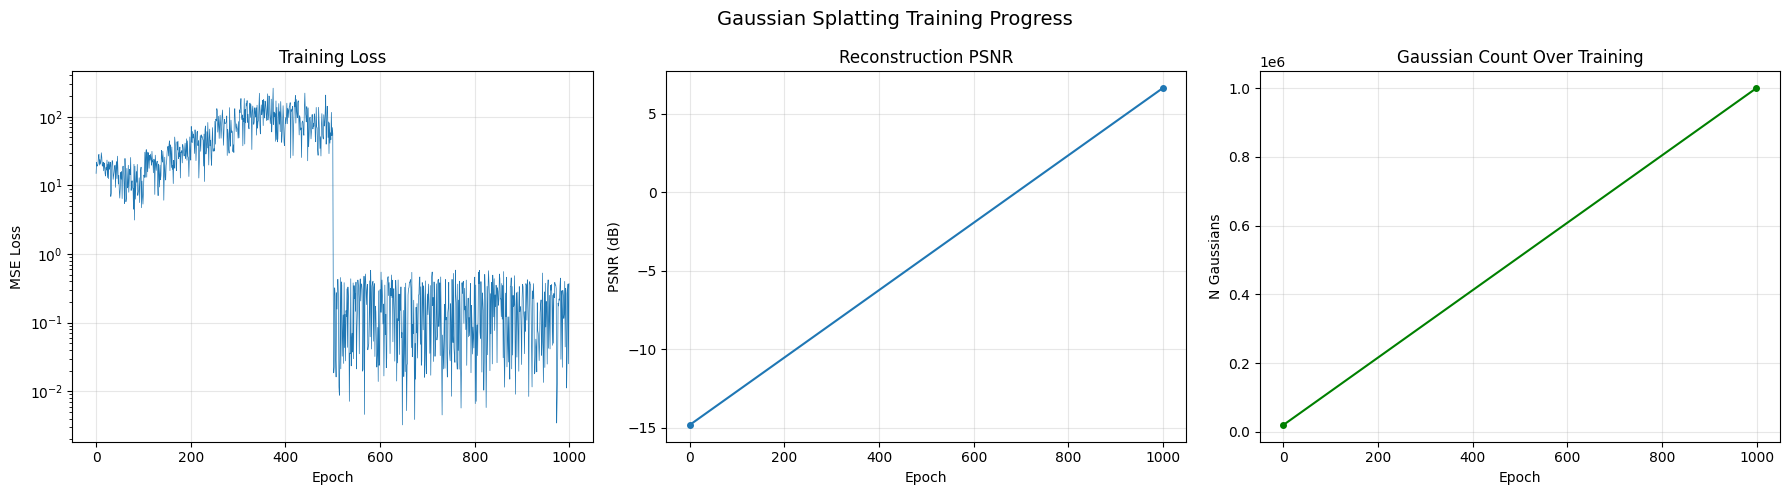

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(history['loss_history'], linewidth=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# PSNR over time
epochs = [m['epoch'] for m in history['metrics_history']]
psnrs  = [m['psnr'] for m in history['metrics_history']]
axes[1].plot(epochs, psnrs, 'o-', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Reconstruction PSNR')
axes[1].grid(True, alpha=0.3)

# Number of Gaussians
n_gauss = [m['n_gaussians'] for m in history['metrics_history']]
axes[2].plot(epochs, n_gauss, 'o-', markersize=4, color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('N Gaussians')
axes[2].set_title('Gaussian Count Over Training')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Gaussian Splatting Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Evaluate Reconstruction Quality

In [ ]:
# ── Render the full reconstructed volume (optimised block-by-block) ──────
# Reload to pick up the rewritten render_full_spatial
import importlib, types
import gs3d.optimizer
importlib.reload(gs3d.optimizer)
from gs3d.optimizer import GaussianOptimizer as _GO
gs_optimizer.render_full_spatial = types.MethodType(_GO.render_full_spatial, gs_optimizer)
gs_optimizer._eval_block_precomputed = _GO._eval_block_precomputed  # static method

print("Rendering full volume...")
print("  Optimisations: precomputed prec + small blocks + vectorised bbox cull")
t0 = time.time()

reconstruction = gs_optimizer.render_full_spatial(
    block_size=(16, 64, 64), verbose=True)

render_time = time.time() - t0
print(f"\n✅ Rendered in {render_time:.1f}s")
print(f"   Shape: {reconstruction.shape}")
print(f"   Range: [{reconstruction.min():.4f}, {reconstruction.max():.4f}]")

# Denormalise
reconstruction_denorm = reconstruction * vol_range + vol_min

Rendering full volume...
  Optimisations: precomputed prec + small blocks + vectorised bbox cull
  Precomputed prec/margins for 1,000,000 Gaussians  (prec: 36 MB)


  Block 272/5440  N_local=900  elapsed=29s  ETA=545s
  Block 544/5440  N_local=743  elapsed=59s  ETA=527s
  Block 816/5440  N_local=947  elapsed=81s  ETA=460s
  Block 1088/5440  N_local=1,319  elapsed=109s  ETA=436s
  Block 1360/5440  N_local=175  elapsed=127s  ETA=382s


In [ ]:
# ── Quantitative metrics ────────────────────────────────────────────────
mse_val = mse(reconstruction, target_norm)
data_range = float(target_norm.max() - target_norm.min())
psnr_val = psnr(mse_val, data_range)

# SSIM (on a subset of slices for speed)
print("Computing SSIM (this may take a moment)...")
n_slices_ssim = min(50, D)
step = max(1, D // n_slices_ssim)
ssim_val = ssim_3d(
    reconstruction[::step],
    target_norm[::step],
)

# Compression ratio
original_bytes = target_volume.numel() * 4  # float32
model_bytes = model.state_size_bytes()
cr = compression_ratio(target_volume.shape, model_bytes, dtype_bits=32)

print(f"\n{'='*50}")
print(f"📊 RECONSTRUCTION QUALITY")
print(f"{'='*50}")
print(f"  MSE:               {mse_val:.6f}")
print(f"  PSNR:              {psnr_val:.2f} dB")
print(f"  SSIM:              {ssim_val:.4f}")
print(f"")
print(f"📦 COMPRESSION")
print(f"  Original volume:   {original_bytes / 1e6:.1f} MB ({target_volume.shape})")
print(f"  GS model:          {model_bytes / 1e6:.2f} MB ({model.n_gaussians:,} Gaussians)")
print(f"  Compression ratio: {cr:.1f}×")
print(f"{'='*50}")

Computing SSIM (this may take a moment)...

📊 RECONSTRUCTION QUALITY
  MSE:               0.002774
  PSNR:              25.57 dB
  SSIM:              0.8962

📦 COMPRESSION
  Original volume:   22.1 MB (torch.Size([1, 2160, 2560]))
  GS model:          42.74 MB (971,452 Gaussians)
  Compression ratio: 0.5×


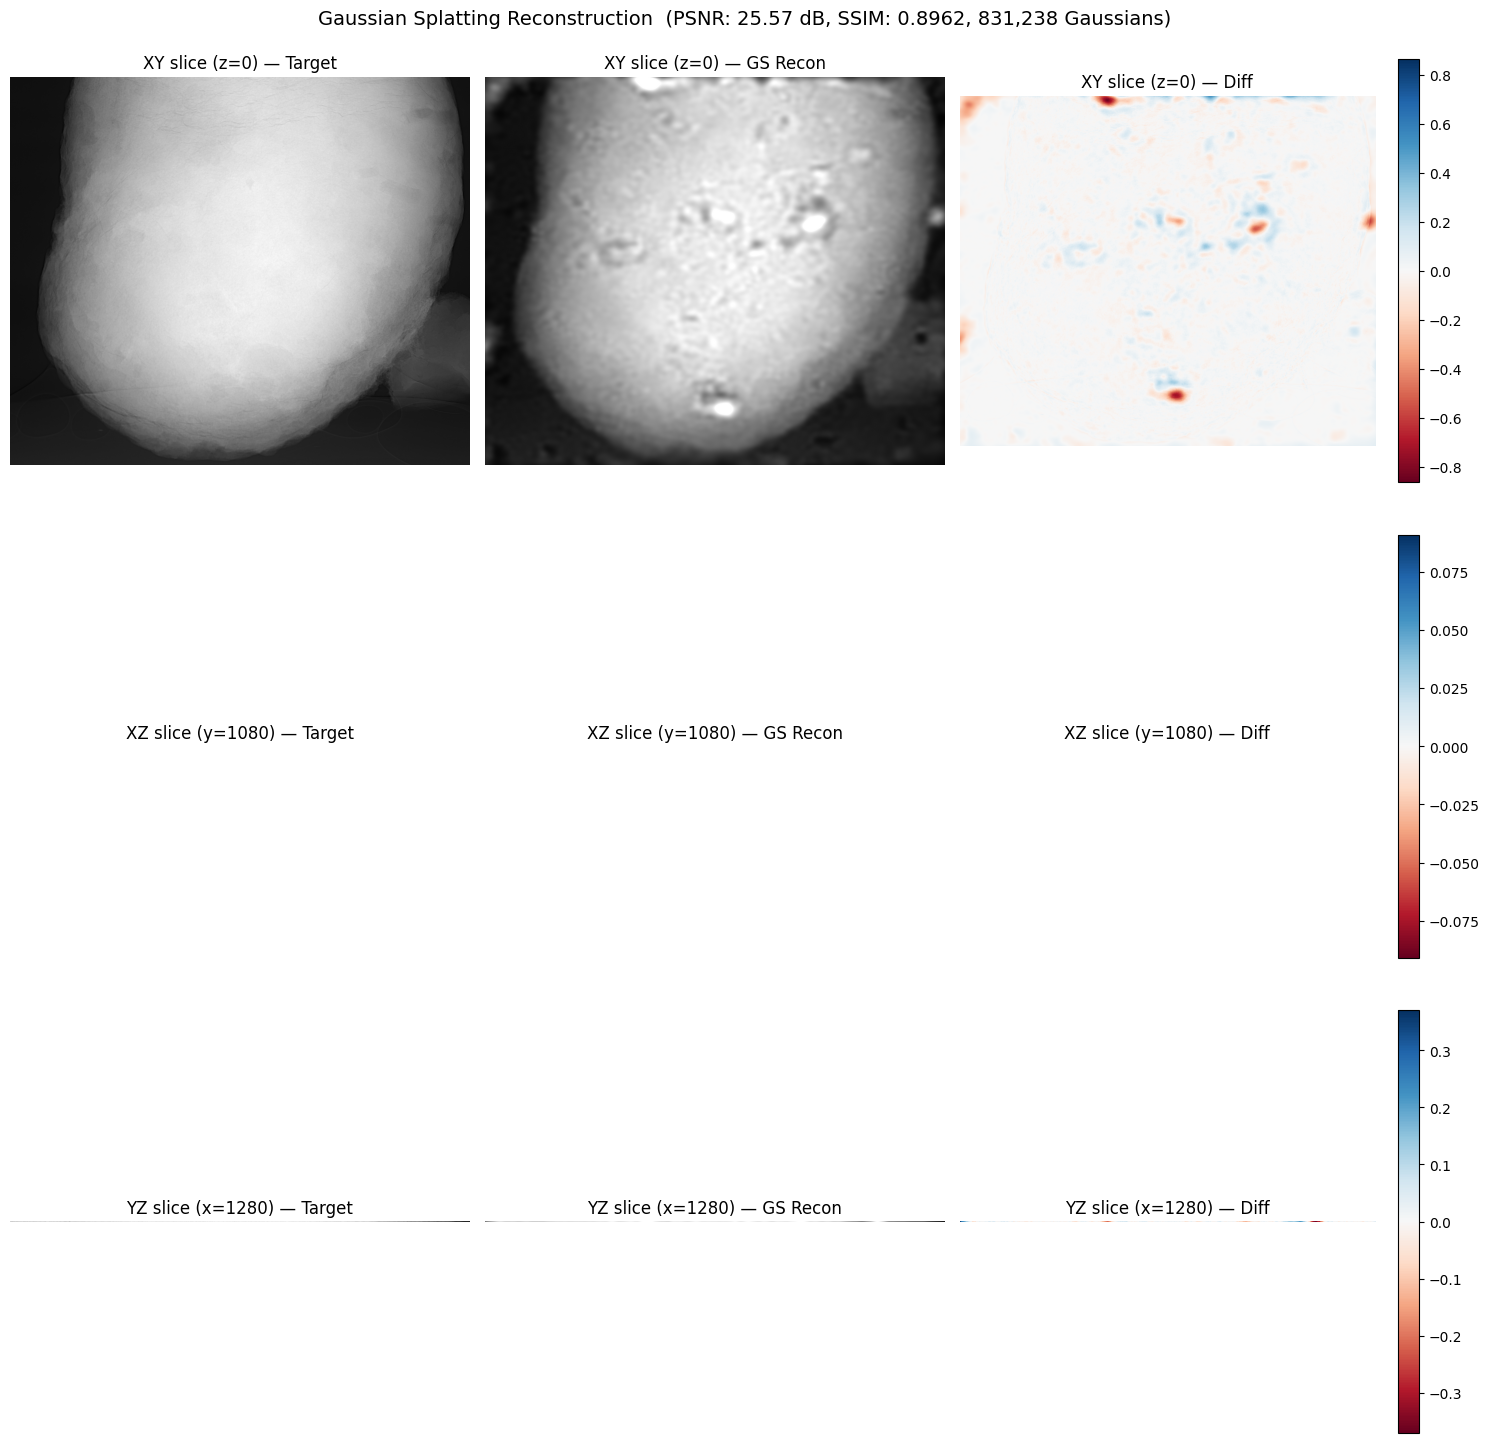

In [ ]:
# ── Visual comparison — orthogonal slices ───────────────────────────────
D, H, W = target_norm.shape
z_mid, y_mid, x_mid = D // 2, H // 2, W // 2
vmin, vmax = float(target_norm.min()), float(target_norm.max())

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
kw = dict(cmap='gray', vmin=vmin, vmax=vmax)

titles = ['Target', 'GS Reconstruction', 'Difference']
slices_target = [
    target_norm[z_mid].numpy(),
    target_norm[:, y_mid, :].numpy(),
    target_norm[:, :, x_mid].numpy(),
]
slices_recon = [
    reconstruction[z_mid].numpy(),
    reconstruction[:, y_mid, :].numpy(),
    reconstruction[:, :, x_mid].numpy(),
]
slice_names = [
    f'XY slice (z={z_mid})',
    f'XZ slice (y={y_mid})',
    f'YZ slice (x={x_mid})',
]

for row in range(3):
    # Target
    axes[row, 0].imshow(slices_target[row], **kw)
    axes[row, 0].set_title(f'{slice_names[row]} — Target')
    axes[row, 0].axis('off')

    # Reconstruction
    axes[row, 1].imshow(slices_recon[row], **kw)
    axes[row, 1].set_title(f'{slice_names[row]} — GS Recon')
    axes[row, 1].axis('off')

    # Difference
    diff = slices_target[row] - slices_recon[row]
    vmax_d = max(abs(diff.min()), abs(diff.max()), 1e-6)
    im = axes[row, 2].imshow(diff, cmap='RdBu', vmin=-vmax_d, vmax=vmax_d)
    axes[row, 2].set_title(f'{slice_names[row]} — Diff')
    axes[row, 2].axis('off')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

plt.suptitle(f'Gaussian Splatting Reconstruction  (PSNR: {psnr_val:.2f} dB, '
             f'SSIM: {ssim_val:.4f}, {model.n_gaussians:,} Gaussians)',
             fontsize=14)
plt.tight_layout()
plt.show()

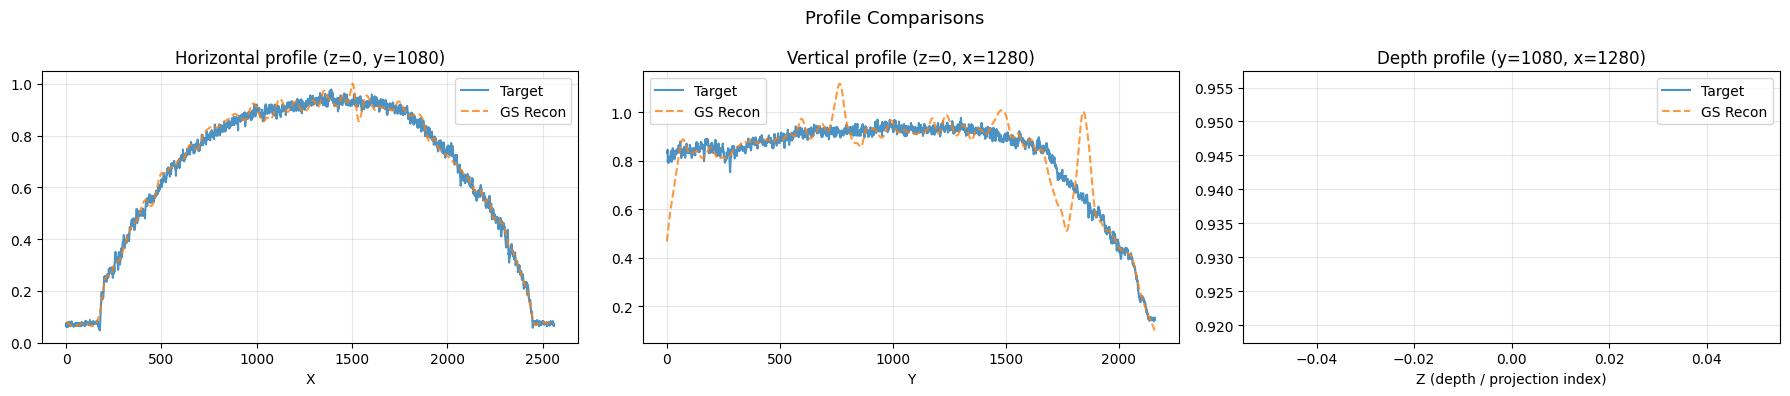

In [ ]:
# ── Line profiles through the centre ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

t_xy = target_norm[z_mid].numpy()
r_xy = reconstruction[z_mid].numpy()

# Horizontal profile
axes[0].plot(t_xy[H//2, :], label='Target', alpha=0.8)
axes[0].plot(r_xy[H//2, :], label='GS Recon', alpha=0.8, linestyle='--')
axes[0].set_title(f'Horizontal profile (z={z_mid}, y={H//2})')
axes[0].set_xlabel('X')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Vertical profile
axes[1].plot(t_xy[:, W//2], label='Target', alpha=0.8)
axes[1].plot(r_xy[:, W//2], label='GS Recon', alpha=0.8, linestyle='--')
axes[1].set_title(f'Vertical profile (z={z_mid}, x={W//2})')
axes[1].set_xlabel('Y')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Depth profile
axes[2].plot(target_norm[:, H//2, W//2].numpy(), label='Target', alpha=0.8)
axes[2].plot(reconstruction[:, H//2, W//2].numpy(), label='GS Recon', alpha=0.8, linestyle='--')
axes[2].set_title(f'Depth profile (y={H//2}, x={W//2})')
axes[2].set_xlabel('Z (depth / projection index)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Profile Comparisons', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Gaussian Statistics

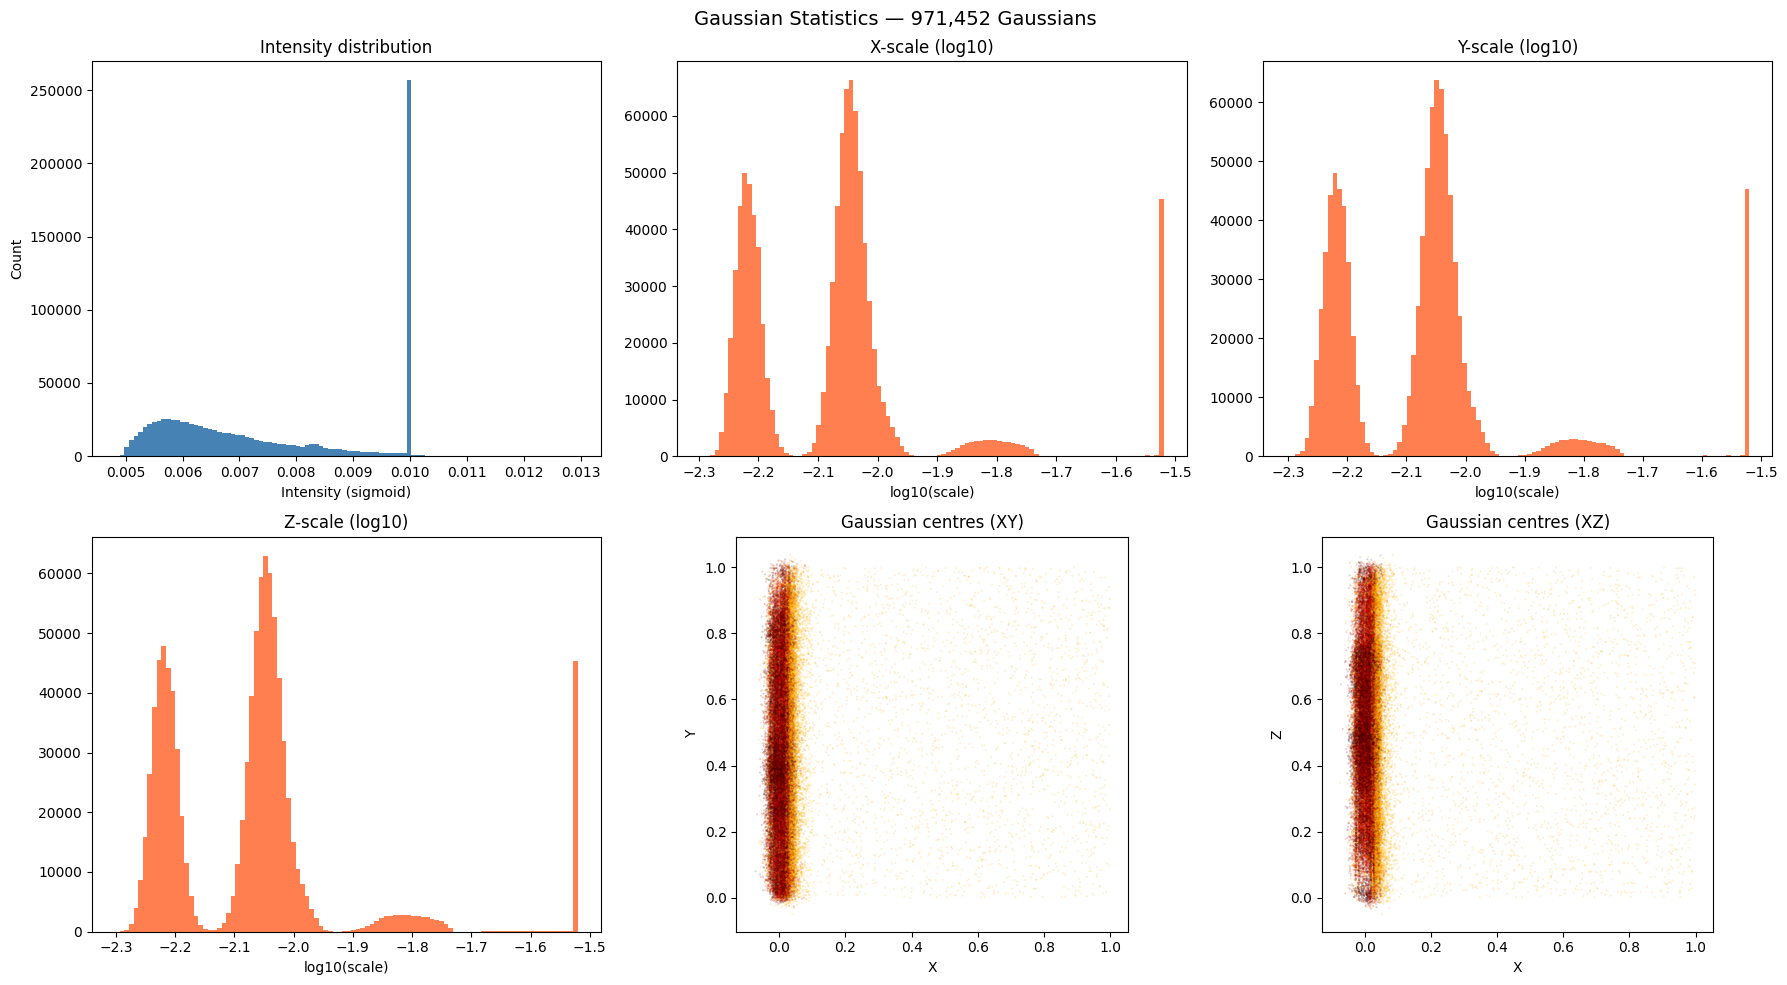


Gaussian statistics:
  N Gaussians:  971,452
  Intensity:    mean=0.0076, median=0.0070
  Scale (mean): X=0.00931, Y=0.00930, Z=0.00930
  Position range: [[-0.07602406 -0.05047398 -0.0481587 ], [0.9999953 1.0425603 1.0415001]]


In [ ]:
# ── Analyse the learned Gaussians ───────────────────────────────────────
with torch.no_grad():
    intensities = model.intensities.cpu().numpy()
    scales = model.scales.cpu().numpy()           # (N, 3)
    means = model.means.cpu().numpy()             # (N, 3)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Intensity distribution
axes[0, 0].hist(intensities, bins=100, color='steelblue', edgecolor='none')
axes[0, 0].set_title('Intensity distribution')
axes[0, 0].set_xlabel('Intensity (sigmoid)')
axes[0, 0].set_ylabel('Count')

# Scale distributions (per axis)
for i, label in enumerate(['X-scale', 'Y-scale', 'Z-scale']):
    ax = axes[0, 1] if i == 0 else axes[0, 2] if i == 1 else axes[1, 0]
    ax.hist(np.log10(scales[:, i] + 1e-10), bins=100, color='coral', edgecolor='none')
    ax.set_title(f'{label} (log10)')
    ax.set_xlabel('log10(scale)')

# Mean positions scatter (2D projections)
sub = np.random.choice(len(means), min(50_000, len(means)), replace=False)
axes[1, 1].scatter(means[sub, 0], means[sub, 1], s=0.1, alpha=0.3, c=intensities[sub], cmap='hot')
axes[1, 1].set_title('Gaussian centres (XY)')
axes[1, 1].set_xlabel('X'); axes[1, 1].set_ylabel('Y')
axes[1, 1].set_aspect('equal')

axes[1, 2].scatter(means[sub, 0], means[sub, 2], s=0.1, alpha=0.3, c=intensities[sub], cmap='hot')
axes[1, 2].set_title('Gaussian centres (XZ)')
axes[1, 2].set_xlabel('X'); axes[1, 2].set_ylabel('Z')
axes[1, 2].set_aspect('equal')

plt.suptitle(f'Gaussian Statistics — {model.n_gaussians:,} Gaussians', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nGaussian statistics:")
print(f"  N Gaussians:  {model.n_gaussians:,}")
print(f"  Intensity:    mean={intensities.mean():.4f}, median={np.median(intensities):.4f}")
print(f"  Scale (mean): X={scales[:,0].mean():.5f}, Y={scales[:,1].mean():.5f}, Z={scales[:,2].mean():.5f}")
print(f"  Position range: [{means.min(axis=0)}, {means.max(axis=0)}]")

## 8. Compression Analysis

In [ ]:
# ── Per-parameter storage breakdown ─────────────────────────────────────
n = model.n_gaussians

breakdown = {
    'Means (N×3)':         n * 3 * 4,
    'Quaternions (N×4)':   n * 4 * 4,
    'Log-scales (N×3)':    n * 3 * 4,
    'Intensity (N×1)':     n * 1 * 4,
}
total_model = sum(breakdown.values())
original = target_volume.numel() * 4  # float32

# If we quantise to float16
total_fp16 = total_model // 2

print(f"{'='*55}")
print(f"📦 STORAGE BREAKDOWN (float32)")
print(f"{'='*55}")
for name, size in breakdown.items():
    print(f"  {name:30s}  {size/1e6:8.2f} MB  ({size/total_model*100:5.1f}%)")
print(f"  {'─'*50}")
print(f"  {'TOTAL (float32)':30s}  {total_model/1e6:8.2f} MB")
print(f"  {'TOTAL (float16)':30s}  {total_fp16/1e6:8.2f} MB")
print(f"")
print(f"  Original volume:  {original/1e6:.1f} MB")
print(f"  CR (float32):     {original/total_model:.1f}×")
print(f"  CR (float16):     {original/total_fp16:.1f}×")
print(f"{'='*55}")

📦 STORAGE BREAKDOWN (float32)
  Means (N×3)                        11.66 MB  ( 27.3%)
  Quaternions (N×4)                  15.54 MB  ( 36.4%)
  Log-scales (N×3)                   11.66 MB  ( 27.3%)
  Intensity (N×1)                     3.89 MB  (  9.1%)
  ──────────────────────────────────────────────────
  TOTAL (float32)                    42.74 MB
  TOTAL (float16)                    21.37 MB

  Original volume:  22.1 MB
  CR (float32):     0.5×
  CR (float16):     1.0×


## 9. Save Model

In [ ]:
save_dir = Path('checkpoints_gs3d')
save_dir.mkdir(exist_ok=True)

model_path = save_dir / 'gs3d_model.pt'
model.save(str(model_path))
print(f"✅ Model saved to {model_path}")
print(f"   File size: {model_path.stat().st_size / 1e6:.2f} MB")

# Save reconstruction
recon_path = save_dir / 'reconstruction_gs3d.npy'
np.save(recon_path, reconstruction_denorm.numpy())
print(f"✅ Reconstruction saved to {recon_path}")

# Save metrics
import json
metrics_summary = {
    'mse': mse_val,
    'psnr_db': psnr_val,
    'ssim': ssim_val,
    'n_gaussians': model.n_gaussians,
    'model_size_mb': model.state_size_bytes() / 1e6,
    'original_size_mb': original_bytes / 1e6,
    'compression_ratio': cr,
    'training_time_s': history['training_time'],
    'volume_shape': list(target_volume.shape),
    'num_epochs': optim_config.num_epochs,
}
with open(save_dir / 'metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print(f"✅ Metrics saved to {save_dir / 'metrics.json'}")

✅ Model saved to checkpoints_gs3d/gs3d_model.pt
   File size: 42.75 MB
✅ Reconstruction saved to checkpoints_gs3d/reconstruction_gs3d.npy
✅ Metrics saved to checkpoints_gs3d/metrics.json


## 10. Summary

| Metric | Value |
|--------|-------|
| Method | 3D Gaussian Splatting (gs3d) |
| Representation | Σ = R·S·S^T·R^T  (rotation + anisotropic scale) |
| Optimiser | AdamW + adaptive density control |
| Adaptive control | Prune low-intensity, clone at high-gradient, split large Gaussians |

In [ ]:
# Final summary table
print(f"\n{'='*60}")
print(f"  3D GAUSSIAN SPLATTING — FINAL RESULTS")
print(f"{'='*60}")
print(f"  Volume shape:        {tuple(target_volume.shape)}")
print(f"  Total voxels:        {target_volume.numel():,}")
print(f"  N Gaussians:         {model.n_gaussians:,}")
print(f"")
print(f"  MSE:                 {mse_val:.6f}")
print(f"  PSNR:                {psnr_val:.2f} dB")
print(f"  SSIM:                {ssim_val:.4f}")
print(f"")
print(f"  Original size:       {original_bytes/1e6:.1f} MB")
print(f"  GS model (fp32):     {model.state_size_bytes()/1e6:.2f} MB")
print(f"  Compression ratio:   {cr:.1f}×")
print(f"  Training time:       {history['training_time']:.1f}s")
print(f"{'='*60}")


  3D GAUSSIAN SPLATTING — FINAL RESULTS
  Volume shape:        (1, 2160, 2560)
  Total voxels:        5,529,600
  N Gaussians:         971,452

  MSE:                 0.002774
  PSNR:                25.57 dB
  SSIM:                0.8962

  Original size:       22.1 MB
  GS model (fp32):     42.74 MB
  Compression ratio:   0.5×
  Training time:       781.8s
